In [ ]:
USR_NAME = 'thebeo2004'
REPO_NAME = 'AMBER'

!git clone https://{USR_NAME}@github.com/{USR_NAME}/{REPO_NAME}.git
%cd /kaggle/working/{REPO_NAME}
!git checkout cascade-anomaly
!git submodule update --init --recursive

In [ ]:
!uv pip install --system -q -r pyproject.toml
!pip install -q ninja
%cd detrex/detectron2
!uv pip install --system -q -e . --no-build-isolation
%cd ..
!uv pip install --system -q -e . --no-build-isolation
%cd /kaggle/working/{REPO_NAME}/anomalib
!uv pip install --system -q -e .

In [ ]:
%cd /kaggle/working/AMBER
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from thop import profile

# Import models & inits
from src.utils import load_raddino
from src.memory_bank.anomaly_raddino import AnomalyRadDINO
from src.memory_bank.anomaly_detection import (
    init_anomaly_model_for_inference, 
    init_aamb_model_for_inference, 
    init_anatomy_segmentation_model
)


/kaggle/working/SAGE


/kaggle/working/SAGE/detrex/detrex/layers/dcn_v3.py:23: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd
/kaggle/working/SAGE/detrex/detrex/layers/dcn_v3.py:52: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  @custom_bwd
/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/usr/local/lib/python3.12/dist-packages/FrEIA/modules/all_in_one_block.py:66: SyntaxWarning: invalid escape sequence '\m'
  Initial value for the global affine scaling :math:`s_\mathrm{global}`.


In [2]:
RADDINO_CKPT = "/kaggle/input/models/thebeo182004/raddino-vitb14-topad16/pytorch/default/1/rad_dino_vitb14_detrex_ready.pth"

v1_dirs = [
    "/kaggle/input/notebooks/thebeo182004/anomalyraddinov1-vindrcxr-1-1-0-1-8",
    "/kaggle/input/notebooks/thebeo2004/anomalyraddinov1-vindrcxr-5-1-0-1-9",
    "/kaggle/input/notebooks/thebeo2004/anomalyraddinov1-vindrcxr-10-1-0-1-10",
    "/kaggle/input/notebooks/thebeo182004/anomalyraddinov1-vindrcxr-20-1-0-1-11",
    "/kaggle/input/notebooks/thebeo182004/1-1-1-anomalyraddino-50-1-0" 
]
v1_paths = [os.path.join(d, "raddino_memory_bank.pt") for d in v1_dirs]

v2_dirs = [
    "/kaggle/input/notebooks/thebeo182004/anomalyraddinov2-vindrcxr-1-1-0-1-8",
    "/kaggle/input/notebooks/thebeo182004/anomalyraddinov2-vindrcxr-5-1-0-1-9",
    "/kaggle/input/notebooks/chihoangf/anomalyraddinov2-vindrcxr-10-1-0-1-10",
    "/kaggle/input/notebooks/thebeo182004/anomalyraddinov2-vindrcxr-20-1-0-1-11",
    "/kaggle/input/notebooks/thebeo182004/anomalyraddinov2-vindrcxr-50-1-0-1-1" 
]
v2_paths = [os.path.join(d, "aamb_memory_bank.pt") if not os.path.exists(os.path.join(d, "raddino_memory_bank.pt")) else os.path.join(d, "raddino_memory_bank.pt") for d in v2_dirs] 

In [18]:

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

SELECTED_ANATOMIES = ['Clavicle', 'Lung', 'Heart', 'Facies Diaphragmatica', 'Mediastinum']

case_labels = ['N=1\np=1.0', 'N=5\np=1.0', 'N=10\np=1.0', 'N=20\np=1.0', 'N=50+\np=1.0*']

# ==========================================
# 1. SETUP THÔNG SỐ VÀ ĐO BACKBONE/SEG STATIC FLOPs
# ==========================================

Q_patches = 4096 # (1024 // 16) ** 2
D_dim = 768

# Simulate dummy sample
dummy_input_rgb = torch.randn(1, 3, 1024, 1024).to(device)
dummy_input_xrv = torch.randn(1, 1, 512, 512).to(device) # Thường torchxrayvision transform về 512
dummy_masks = torch.randn(1, 5, 1024, 1024).to(device)

# Approximate the percentage coverage of each anatomy region on the entirn CXR image
percentage_coverage = np.array([0.03, 0.3, 0.09, 0.25, 0.03])

print("Đang profiling Static Backbone và Segmentation...")
base_model = AnomalyRadDINO(raddino_model=load_raddino(RADDINO_CKPT).to(device), patch_size=16).to(device)
macs_backbone, _ = profile(base_model.feature_encoder, inputs=(dummy_input_rgb, ), verbose=False)
base_bb_gflops = (macs_backbone * 2) / 1e9

seg_model = init_anatomy_segmentation_model(device)
macs_seg, _ = profile(seg_model, inputs=(dummy_input_xrv, ), verbose=False)
seg_gflops = (macs_seg * 2) / 1e9

print(f" -> ViT Backbone : {base_bb_gflops:.2f} GFLOPs")
print(f" -> PSPNet Seg   : {seg_gflops:.2f} GFLOPs\n")
del base_model, seg_model; torch.cuda.empty_cache()

# ==========================================
# 2. VÒNG LẶP HYBRID PROFILING CHO CÁC CASES
# ==========================================
v1_gflops_list = []
v2_gflops_list = []

for idx, (label, v1_p, v2_p) in enumerate(zip(case_labels, v1_paths, v2_paths)):
    print(f"[{label.replace(chr(10), ' ')}]")
    
    # --- V1 (PatchCore) ---
    model_v1, _ = init_anomaly_model_for_inference(RADDINO_CKPT, v1_p, num_neighbours=1)
    bank_size_v1 = model_v1.memory_bank.shape[0] if hasattr(model_v1, 'memory_bank') else 0
    
    macs_v1, _ = profile(model_v1, inputs=(dummy_input_rgb,), verbose=False)
    v1_nn_gflops = (macs_v1 * 2) / 1e9
    
    # Tính tay phần KNN
    v1_knn_gflops = (2 * Q_patches * bank_size_v1 * D_dim) / 1e9
    total_gflops_v1 = v1_nn_gflops + v1_knn_gflops
    v1_gflops_list.append(total_gflops_v1)
    
    print(f" - V1 | Bank: {bank_size_v1:<6} | Total GFLOPs: {total_gflops_v1:.2f} (BB: {v1_nn_gflops:.2f} + KNN: {v1_knn_gflops:.2f})")
    del model_v1; torch.cuda.empty_cache()

    # --- V2 (AAMB) ---
    model_v2, _ = init_aamb_model_for_inference(RADDINO_CKPT, v2_p, num_anatomies=5, num_neighbours=1)
    
    macs_v2, _ = profile(model_v2, inputs=(dummy_input_rgb, dummy_masks), verbose=False)
    v2_nn_gflops = ((macs_v2 * 2) / 1e9) + seg_gflops 
    
    # Tính tay phần KNN 
    Q_i_avg = Q_patches / 5 # Giả định patch phân chia đều cho 5 mask area
    v2_knn_gflops = 0
    total_v2_bank = 0
    
    for _ , (k, v) in enumerate(model_v2.state_dict().items()):
        if 'memory_bank' in k:
            M_i = v.shape[0]
            total_v2_bank += M_i
            anatomy_knn_gflops = (2 * (Q_patches * percentage_coverage[_]) * M_i * D_dim) / 1e9
            print(f"Bank {SELECTED_ANATOMIES[_]} has GFLOPs of", anatomy_knn_gflops)
            v2_knn_gflops += anatomy_knn_gflops
            
    total_gflops_v2 = v2_nn_gflops + v2_knn_gflops
    v2_gflops_list.append(total_gflops_v2)
    
    print(f" - V2 | Bank: {total_v2_bank:<6} | Total GFLOPs: {total_gflops_v2:.2f} (BB+Seg: {v2_nn_gflops:.2f} + KNN: {v2_knn_gflops:.2f})")
    print("-" * 50)
    del model_v2; torch.cuda.empty_cache()


Đang profiling Static Backbone và Segmentation...
[06/22 09:58:22 timm backbone]: backbone out_indices: (11,)
[06/22 09:58:22 timm backbone]: backbone out_channels: [768]
[06/22 09:58:22 timm backbone]: backbone out_strides: [16]
 -> ViT Backbone : 701.39 GFLOPs
 -> PSPNet Seg   : 544.83 GFLOPs

[N=1 p=1.0]
[06/22 09:58:25 timm backbone]: backbone out_indices: (11,)
[06/22 09:58:25 timm backbone]: backbone out_channels: [768]
[06/22 09:58:25 timm backbone]: backbone out_strides: [16]
Loading Memory Bank from /kaggle/input/notebooks/thebeo182004/anomalyraddinov1-vindrcxr-1-1-0-1-8/raddino_memory_bank.pt...
 - V1 | Bank: 4096   | Total GFLOPs: 727.16 (BB: 701.39 + KNN: 25.77)
[06/22 09:58:27 timm backbone]: backbone out_indices: (11,)
[06/22 09:58:27 timm backbone]: backbone out_channels: [768]
[06/22 09:58:27 timm backbone]: backbone out_strides: [16]
Loading AAMB Memory Banks from /kaggle/input/notebooks/thebeo182004/anomalyraddinov2-vindrcxr-1-1-0-1-8/raddino_memory_bank.pt...
Bank Cl

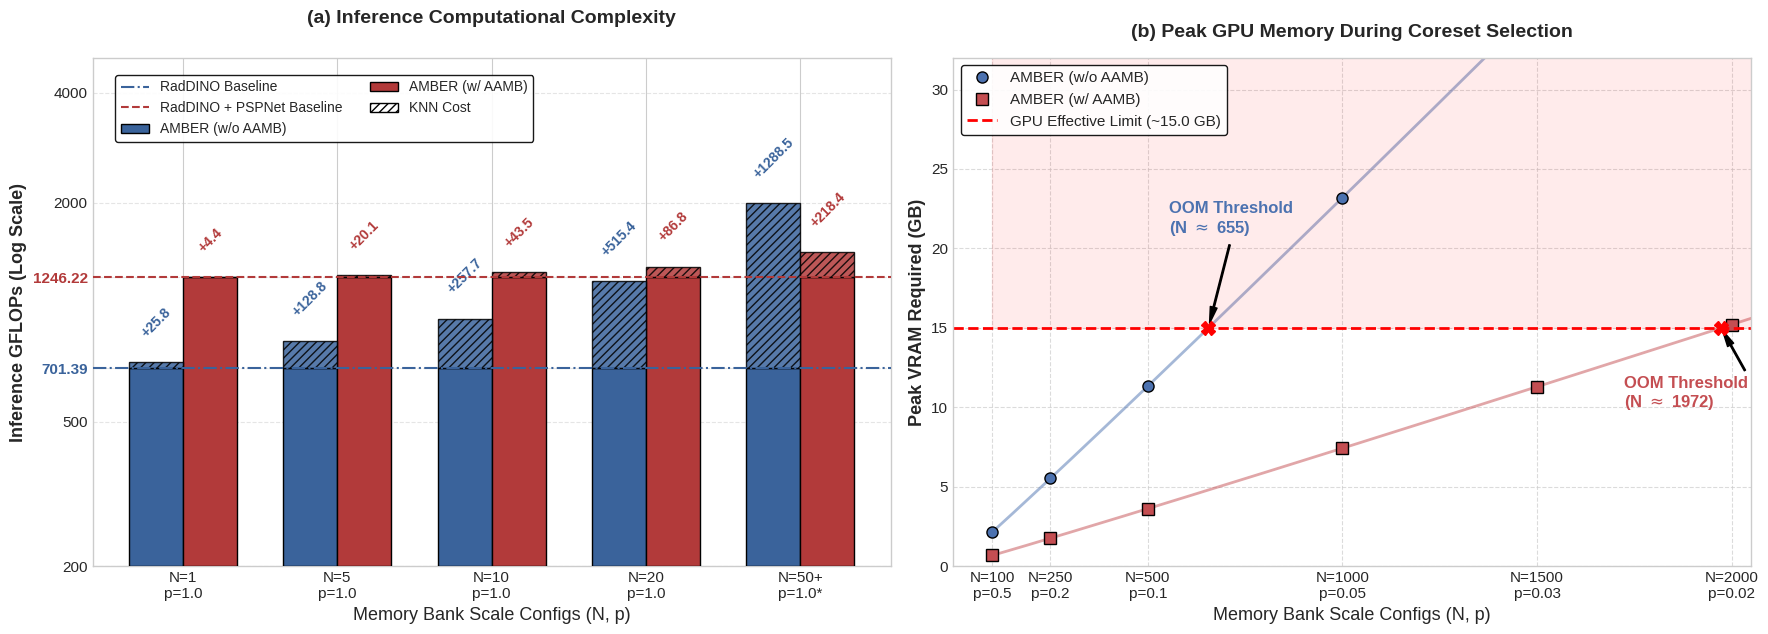

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import interp1d
import matplotlib.patches as mpatches

# ==========================================
# 0. SETUP STYLE BÁO CÁO KHOA HỌC
# ==========================================
sns.reset_orig()
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 13,
    'axes.titlesize': 14,
    'legend.fontsize': 11,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11
})

fig, axes = plt.subplots(1, 2, figsize=(18, 6.5))

color_v1 = '#4c72b0'
color_v2 = '#c44e52'

# ==========================================
# PLOT 1 (TRÁI): INFERENCE GFLOPS COMPARISON
# ==========================================
ax1 = axes[0]

plot1_labels = ['N=1\np=1.0', 'N=5\np=1.0', 'N=10\np=1.0', 'N=20\np=1.0', 'N=50+\np=1.0*']
num_bars = len(plot1_labels)
x = np.arange(num_bars)
width = 0.35

# Tính toán các mức Baseline cố định
v1_base_gflops = base_bb_gflops
v2_base_gflops = base_bb_gflops + seg_gflops

# Bóc tách phần chi phí thuần của KNN (Total - Baseline)
v1_knn_list = [total - v1_base_gflops for total in v1_gflops_list]
v2_knn_list = [total - v2_base_gflops for total in v2_gflops_list]

y_min = 200.0 
c_v1 = '#3A639B' # Xanh chủ đạo cho phương pháp cũ
c_v2 = '#B23A3A' # Đỏ chủ đạo cho phương pháp đề xuất

# 1. VẼ PHẦN BASELINE (Móng cột)
ax1.bar(x - width/2, [v1_base_gflops - y_min]*num_bars, width, bottom=y_min, 
        label='AMBER (w/o AAMB)', color=c_v1, edgecolor='black', zorder=3)
ax1.bar(x + width/2, [v2_base_gflops - y_min]*num_bars, width, bottom=y_min, 
        label='AMBER (w/ AAMB)', color=c_v2, edgecolor='black', zorder=3)

# 2. VẼ PHẦN KNN COST (Xếp chồng) - Không truyền label ở đây để tránh trùng lặp màu
ax1.bar(x - width/2, v1_knn_list, width, bottom=[v1_base_gflops]*num_bars, 
        color=c_v1, alpha=0.85, edgecolor='black', hatch='////', zorder=3)
ax1.bar(x + width/2, v2_knn_list, width, bottom=[v2_base_gflops]*num_bars, 
        color=c_v2, alpha=0.85, edgecolor='black', hatch='////', zorder=3)

# 3. ĐƯỜNG KẺ NGANG THAM CHIẾU
ax1.axhline(y=v1_base_gflops, color=c_v1, linestyle='-.', linewidth=1.5, label='RadDINO Baseline', zorder=4)
ax1.axhline(y=v2_base_gflops, color=c_v2, linestyle='--', linewidth=1.5, label='RadDINO + PSPNet Baseline', zorder=4)

# 4. THÊM CÁC CON SỐ +GFLOPS THỂ HIỆN CHI PHÍ TRUY VẤN KNN
for i in range(num_bars):
    ax1.text(x[i] - width/2, v1_gflops_list[i] * 1.15, f'+{v1_knn_list[i]:.1f}', 
             ha='center', va='bottom', fontsize=10, fontweight='bold', color=c_v1, rotation=45)
    ax1.text(x[i] + width/2, v2_gflops_list[i] * 1.15, f'+{v2_knn_list[i]:.1f}', 
             ha='center', va='bottom', fontsize=10, fontweight='bold', color=c_v2, rotation=45)

# 5. CẤU HÌNH TRỤC X, TRỤC Y VÀ HIỂN THỊ LOG SCALE
ax1.set_ylabel('Inference GFLOPs (Log Scale)', fontweight='bold')
ax1.set_xlabel('Memory Bank Scale Configs (N, p)')
ax1.set_title('(a) Inference Computational Complexity', fontweight='bold', pad=25)
ax1.set_xticks(x)
ax1.set_xticklabels(plot1_labels)
ax1.set_yscale('log')

y_ticks_values = [200, 500, v1_base_gflops, v2_base_gflops, 2000, 4000]
y_ticks_labels = ['200', '500', f'{v1_base_gflops:.2f}', f'{v2_base_gflops:.2f}', '2000', '4000']

ax1.set_yticks(y_ticks_values)
ax1.set_yticklabels(y_ticks_labels)

# Đổi màu chữ riêng cho 2 mốc số Baseline
for tick_label in ax1.get_yticklabels():
    if tick_label.get_text() == f'{v1_base_gflops:.2f}':
        tick_label.set_color(c_v1)
        tick_label.set_fontweight('bold')
    elif tick_label.get_text() == f'{v2_base_gflops:.2f}':
        tick_label.set_color(c_v2)
        tick_label.set_fontweight('bold')

ax1.set_ylim(bottom=y_min, top=5000) 
ax1.grid(axis='y', linestyle='--', alpha=0.5, zorder=0)

# ==========================================
# 6. CẤU HÌNH LEGEND TÙY CHỈNH (THÊM HỌA TIẾT GẠCH CHÉO)
# ==========================================
# Lấy các thành phần legend hiện tại (2 cột màu đặc, 2 đường kẻ ngang)
handles, labels = ax1.get_legend_handles_labels()

# Tạo một "Patch" giả lập có nền trắng, viền đen và họa tiết gạch chéo để đại diện cho KNN
knn_patch = mpatches.Patch(facecolor='white', edgecolor='black', hatch='////', label='KNN Cost')

# Thêm patch giả lập này vào danh sách Legend
handles.append(knn_patch)
labels.append('KNN Cost')

# Vẽ Legend với 5 thành phần, chia 2 cột để tiết kiệm diện tích và hiển thị cân đối
ax1.legend(handles=handles, labels=labels, loc='upper left', bbox_to_anchor=(0.02, 0.98), 
           frameon=True, framealpha=0.9, facecolor='white', edgecolor='black', fontsize=10, ncol=2)
# ==========================================
# PLOT 2 (PHẢI): PEAK VRAM FOR CORESET SUBSAMPLING
# ==========================================
def estimate_peak_vram_gb(num_patches):
    if num_patches <= 1:
        return 0
    D_prime = (4 * np.log(num_patches)) / 0.162
    bytes_peak = num_patches * 4 * (768 + 2 * D_prime)
    return bytes_peak / (1024**3)

N_cases = np.array([100, 250, 500, 1000, 1500, 2000])

# Nhãn hiển thị chi tiết (N, p) cho Plot 2
plot2_labels = [
    'N=100\np=0.5', 'N=250\np=0.2', 'N=500\np=0.1', 
    'N=1000\np=0.05', 'N=1500\np=0.03', 'N=2000\np=0.02'
]

empirical_lung_patches_raw = [
    [136790, 134712, 134401, 140443],
    [341659, 334249, 334161, 347332],
    [678697, 681439, 674997, 684608],
    [1357028, 1366099, 1366409, 1360215],
    [2042615, 2039775, 2051160, 2040686],
    [2721479, 2712058, 2739076, 2719549]
]

v2_empirical_patches_mean = np.array([np.mean(runs) for runs in empirical_lung_patches_raw])

v1_peak_points = [estimate_peak_vram_gb(n * 4096) for n in N_cases]
v2_peak_empirical_points = [estimate_peak_vram_gb(p) for p in v2_empirical_patches_mean]

empirical_ratio = np.mean(v2_empirical_patches_mean / (N_cases * 4096))
N_smooth = np.linspace(100, 2100, 300)
v1_peak_smooth = [estimate_peak_vram_gb(n * 4096) for n in N_smooth]
v2_peak_smooth = [estimate_peak_vram_gb(n * 4096 * empirical_ratio) for n in N_smooth]

t4_limit_gb = 15.0
f_v1 = interp1d(v1_peak_smooth, N_smooth, bounds_error=False, fill_value="extrapolate")
f_v2 = interp1d(v2_peak_smooth, N_smooth, bounds_error=False, fill_value="extrapolate")
oom_v1 = float(f_v1(t4_limit_gb))
oom_v2 = float(f_v2(t4_limit_gb))

ax2 = axes[1]
ax2.plot(N_smooth, v1_peak_smooth, linewidth=2, color=color_v1, alpha=0.5, zorder=1)
ax2.plot(N_smooth, v2_peak_smooth, linewidth=2, color=color_v2, alpha=0.5, zorder=1)

ax2.plot(N_cases, v1_peak_points, marker='o', linewidth=0, markersize=8, color=color_v1, markeredgecolor='black', label='AMBER (w/o AAMB)', zorder=2)
ax2.plot(N_cases, v2_peak_empirical_points, marker='s', linewidth=0, markersize=8, color=color_v2, markeredgecolor='black', label='AMBER (w/ AAMB)', zorder=2)

ax2.axhline(y=t4_limit_gb, color='red', linestyle='--', linewidth=2, label=f'GPU Effective Limit (~{t4_limit_gb} GB)')
ax2.fill_between(N_smooth, t4_limit_gb, max(v1_peak_smooth) + 5, color='red', alpha=0.08)

# Tìm vị trí N tương đối để scale toạ độ
ax2.plot(oom_v1, t4_limit_gb, 'rX', markersize=10, zorder=4)
ax2.annotate(f'OOM Threshold\n(N $\\approx$ {int(oom_v1)})', xy=(oom_v1, t4_limit_gb), xytext=(oom_v1 - 100, t4_limit_gb + 6),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1.0, headwidth=5), 
             fontweight='bold', color=color_v1)

ax2.plot(oom_v2, t4_limit_gb, 'rX', markersize=10, zorder=4)
ax2.annotate(f'OOM Threshold\n(N $\\approx$ {int(oom_v2)})', xy=(oom_v2, t4_limit_gb), xytext=(oom_v2 - 250, t4_limit_gb - 5),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1.0, headwidth=5), 
             fontweight='bold', color=color_v2)

ax2.set_title('(b) Peak GPU Memory During Coreset Selection', fontweight='bold', pad=15)
ax2.set_xlabel('Memory Bank Scale Configs (N, p)')  # Loại bỏ nhãn trục X theo yêu cầu
ax2.set_ylabel('Peak VRAM Required (GB)', fontweight='bold')

# Setup Grid, Ticks với Extented Limits
ax2.set_xticks(N_cases)
ax2.set_xticklabels(plot2_labels)
ax2.set_xlim(0, 2050) # Đẩy vạch gốc về 0 để không bị khuất nhãn M=100
ax2.set_ylim(0, 32)
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.legend(loc='upper left', frameon=True, framealpha=0.9, facecolor='white', edgecolor='black')

# ==========================================
# FINALIZE
# ==========================================
plt.tight_layout()
plt.show()